[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/exoplanet-archive/2026-07-30-mass-period-trend/notebook.ipynb)

# Is there a real relationship between planet mass and orbital period?

I wanted to look at thousands of confirmed exoplanets at once and see whether there's a visible relationship between how massive a planet is and how long its orbit takes -- and along the way, get a look at the famous 'hot Jupiter' population: giant planets crammed into very short orbits, which was one of the biggest surprises of early exoplanet science.

In [1]:
import pyvo as vo
import numpy as np
import matplotlib.pyplot as plt

svc = vo.dal.TAPService('https://exoplanetarchive.ipac.caltech.edu/TAP')
query = '''
SELECT pl_name, pl_bmasse, pl_orbper, discoverymethod
FROM pscomppars
WHERE pl_bmasse IS NOT NULL AND pl_orbper IS NOT NULL
'''
tab = svc.search(query).to_table()
print(len(tab), 'confirmed planets with mass and period retrieved')

5961 confirmed planets with mass and period retrieved


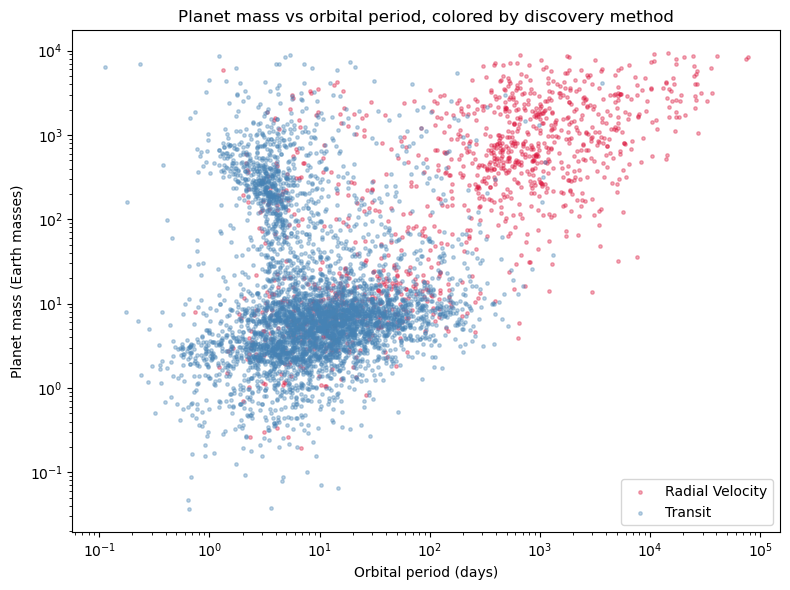

In [2]:
mass = np.array(tab['pl_bmasse'])   # Earth masses
period = np.array(tab['pl_orbper']) # days
method = np.array(tab['discoverymethod'])

plt.figure(figsize=(8,6))
for m, color in [('Radial Velocity', 'crimson'), ('Transit', 'steelblue')]:
    mask = method == m
    plt.scatter(period[mask], mass[mask], s=6, alpha=0.35, label=m, color=color)
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Orbital period (days)')
plt.ylabel('Planet mass (Earth masses)')
plt.legend()
plt.title('Planet mass vs orbital period, colored by discovery method')
plt.tight_layout()
plt.savefig('mass_vs_period.png', dpi=120)
plt.show()

There's no single clean power-law relationship -- instead you see distinct clusters that trace back to how each detection method actually works. Radial velocity surveys are naturally biased toward finding massive planets (they cause a bigger stellar wobble), while transit surveys pick up a wide range of masses but are strongly biased toward short periods, since a planet has to transit often to be confirmed easily. What looks like a 'trend' in this raw data is really mostly a fingerprint of detection bias, not the underlying planet population.

**What I'd look at next:** Restrict to just one detection method at a time before looking for a true underlying mass-period relationship, since mixing methods together mostly just shows their different selection effects.

**Citation:** This research has made use of the NASA Exoplanet Archive, which is operated by the California Institute of Technology, under contract with NASA under the Exoplanet Exploration Program. See https://exoplanetarchive.ipac.caltech.edu/docs/acknowledge.html.